# Image Captioning Demo — Full folder

**IE 7615 Group 8**

This notebook provides an end-to-end interactive evaluation of three model variants:
- **Frozen**: only ProjectionHead is trained, GPT-2 weights frozen
- **FT-4L**: Top 4 GPT-2 transformer layers fine-tuned
- **LoRA**: low-rank adaptation (r=8) applied to GPT-2 attention layers

Each section is self-contained. Run cells top to bottom.

```
Run from project root:
    source .venv/bin/activate
    jupyter notebook demo/demo.ipynb
```

---
## Section 1: Imports and Environment Setup

In [1]:
import os
import sys
import re
import math
import time
import copy
import types
import warnings
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 110,
})

# ── Resolve project root (works when notebook is in demo/ or project root)
DEMO_DIR = Path().resolve()
PROJECT_ROOT = DEMO_DIR.parent if DEMO_DIR.name == 'demo' else DEMO_DIR
sys.path.insert(0, str(PROJECT_ROOT))

# ── Use cached HuggingFace models if available (avoids network calls)
_HF_CACHE = Path.home() / '.cache' / 'huggingface' / 'hub'

def _is_cached(model_id):
    snap = _HF_CACHE / ('models--' + model_id.replace('/', '--')) / 'snapshots'
    if not snap.exists():
        return False
    return any(s.is_dir() for s in snap.iterdir())

if _is_cached('openai/clip-vit-base-patch32') and _is_cached('gpt2'):
    os.environ['TRANSFORMERS_OFFLINE'] = '1'
    print('HuggingFace offline mode: ON (using local cache)')
else:
    print('HuggingFace offline mode: OFF (will download if needed)')

from transformers import CLIPModel, CLIPProcessor, GPT2LMHeadModel, GPT2Tokenizer

# ── Device selection
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f'Device: {DEVICE}')
print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')

HuggingFace offline mode: ON (using local cache)
Device: mps
Project root: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project
PyTorch: 2.11.0


---
## Section 2: Model Architecture Definition

In [2]:
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
GPT2_MODEL_NAME = 'gpt2'
CLIP_DIM        = 512
GPT2_DIM        = 768
PREFIX_LENGTH   = 10


@dataclass
class TrainingConfig:
    """Stub matching the config saved inside each checkpoint."""
    clip_model_name: str   = CLIP_MODEL_NAME
    gpt2_model_name: str   = GPT2_MODEL_NAME
    clip_embedding_dim: int = CLIP_DIM
    gpt2_embedding_dim: int = GPT2_DIM
    prefix_length: int      = PREFIX_LENGTH
    max_token_length: int   = 50
    learning_rate: float    = 5e-4
    batch_size: int         = 16
    epochs: int             = 20
    warmup_ratio: float     = 0.1
    weight_decay: float     = 0.01
    beam_width: int         = 5
    nucleus_top_p: float    = 0.9
    nucleus_temperature: float = 0.8
    early_stopping_patience: int = 3
    log_interval: int       = 50
    seed: int               = 42
    device: str             = DEVICE
    project_root: str       = str(PROJECT_ROOT)
    data_raw_dir: str       = ''
    data_processed_dir: str = ''
    embeddings_dir: str     = ''
    checkpoints_dir: str    = str(PROJECT_ROOT / 'outputs' / 'checkpoints')
    samples_dir: str        = str(PROJECT_ROOT / 'outputs' / 'samples')


# Register stub so torch.load can unpickle old checkpoints
_main = sys.modules.get('__main__', types.ModuleType('__main__'))
if not hasattr(_main, 'TrainingConfig'):
    _main.TrainingConfig = TrainingConfig
    sys.modules['__main__'] = _main


class ProjectionHead(nn.Module):
    """Maps CLIP 512-d embedding to 10 GPT-2 prefix tokens (768-d each)."""

    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_length=10):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        hidden = gpt2_dim * prefix_length
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
        )

    def forward(self, x):
        return self.projection(x).view(-1, self.prefix_length, self.gpt2_dim)


class ClipCaptionModel(nn.Module):
    """Full model: CLIP image embedding -> projection -> GPT-2 decoder."""

    def __init__(self, gpt2_model_name, tokenizer, prefix_length=10):
        super().__init__()
        self.prefix_length = prefix_length
        self.projection = ProjectionHead(CLIP_DIM, GPT2_DIM, prefix_length)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model_name)
        self.gpt2.resize_token_embeddings(len(tokenizer))

    @torch.no_grad()
    def generate(self, embedding, strategy='beam', num_beams=5,
                 temperature=0.5, top_p=0.9, max_new_tokens=40,
                 tokenizer=None):
        self.eval()
        if embedding.dim() == 1:
            embedding = embedding.unsqueeze(0)
        embedding = embedding.to(next(self.parameters()).device)
        prefix = self.projection(embedding)

        common = dict(
            inputs_embeds=prefix,
            max_new_tokens=max_new_tokens,
            min_new_tokens=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            no_repeat_ngram_size=3,
        )
        if strategy == 'greedy':
            common.update(do_sample=False, repetition_penalty=1.5)
        elif strategy == 'beam':
            common.update(do_sample=False, num_beams=num_beams,
                          early_stopping=True, no_repeat_ngram_size=2,
                          length_penalty=1.0)
        elif strategy == 'nucleus':
            common.update(do_sample=True, top_p=top_p,
                          temperature=temperature, top_k=0,
                          repetition_penalty=1.3)

        ids = self.gpt2.generate(**common)
        return tokenizer.decode(ids[0], skip_special_tokens=True).strip()


print('Architecture classes defined.')

Architecture classes defined.


---
## Section 3: Load CLIP Encoder and Model Checkpoints

In [3]:
CHECKPOINT_PATHS = {
    'Frozen': PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model.pt',
    'FT-4L':  PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model_finetuned.pt',
    'LoRA':   PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model_lora.pt',
}

# ── GPT-2 tokenizer
print('Loading GPT-2 tokenizer...')
tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

# ── CLIP encoder (shared, frozen)
print('Loading CLIP ViT-B/32...')
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
print('  CLIP ready')

# ── Build one base model template and deepcopy for each checkpoint
print('Building base GPT-2 template...')
base_template = ClipCaptionModel(GPT2_MODEL_NAME, tokenizer, PREFIX_LENGTH)
base_state = base_template.state_dict()

loaded_models = {}

for name, ckpt_path in CHECKPOINT_PATHS.items():
    if not ckpt_path.exists():
        print(f'  {name}: checkpoint not found at {ckpt_path}')
        continue

    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    state = {k.replace('module.', ''): v for k, v in state.items()}

    # Handle PEFT / LoRA checkpoint formats
    has_base_model = any('base_model.model.' in k for k in state)
    has_base_layer = any('base_layer.' in k for k in state)
    has_lora_keys  = any('lora_A' in k or 'lora_B' in k for k in state)

    if has_base_model or has_base_layer:
        clean = {}
        for k, v in state.items():
            k2 = k.replace('gpt2.base_model.model.', 'gpt2.')
            if 'lora_A' in k2 or 'lora_B' in k2:
                continue
            k2 = k2.replace('.base_layer.', '.')
            clean[k2] = v
        state = clean
    elif has_lora_keys:
        state = {k: v for k, v in state.items()
                 if 'lora_A' not in k and 'lora_B' not in k
                 and 'base_layer' not in k}

    merged = dict(base_state)
    merged.update(state)

    m = copy.deepcopy(base_template)
    missing, unexpected = m.load_state_dict(merged, strict=False)
    real_missing = [k for k in missing if 'lora' not in k.lower()]
    if real_missing:
        print(f'  {name}: {len(real_missing)} real missing keys')
    m.to(DEVICE).eval()
    loaded_models[name] = m
    print(f'  {name}: loaded from {ckpt_path.name}')

print(f'\nModels ready: {list(loaded_models.keys())}')

Loading GPT-2 tokenizer...
Loading CLIP ViT-B/32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CLIP ready
Building base GPT-2 template...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Frozen: loaded from best_model.pt
  FT-4L: loaded from best_model_finetuned.pt
  LoRA: loaded from best_model_lora.pt

Models ready: ['Frozen', 'FT-4L', 'LoRA']


---
## Section 4: Utility Functions

In [4]:
@torch.no_grad()
def encode_image(pil_img):
    """Run CLIP on a PIL image, return L2-normalized 512-d embedding."""
    if pil_img.mode != 'RGB':
        pil_img = pil_img.convert('RGB')
    inputs = clip_processor(images=pil_img, return_tensors='pt').to(DEVICE)
    vision_out = clip_model.vision_model(pixel_values=inputs['pixel_values'])
    pooled = vision_out.pooler_output
    emb = clip_model.visual_projection(pooled)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.squeeze(0).cpu()


def clean_caption(text, max_sentences=1):
    """Trim to the first N complete sentences."""
    text = text.strip()
    if not text:
        return text
    parts = re.split(r'(?<=[.!?])\s+', text)
    parts = [s.strip() for s in parts if s.strip()]
    if max_sentences and max_sentences > 0:
        text = ' '.join(parts[:max_sentences])
    if text and text[-1] not in '.!?':
        text += '.'
    return text


def load_image_folder(folder_path, extensions=('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
    """Return sorted list of image paths from a folder."""
    folder = Path(folder_path)
    if not folder.exists():
        raise FileNotFoundError(f'Folder not found: {folder}')
    paths = sorted([p for p in folder.iterdir()
                    if p.suffix.lower() in extensions])
    return paths


# ── Reference-based metrics (require ground-truth captions)
def compute_bleu(hypothesis, references, n=4):
    """Sentence-level BLEU-n with smoothing."""
    import nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    sf = SmoothingFunction().method1
    hyp_tok = nltk.word_tokenize(hypothesis.lower())
    ref_toks = [nltk.word_tokenize(r.lower()) for r in references]
    weights = tuple([1.0 / n] * n)
    return sentence_bleu(ref_toks, hyp_tok, weights=weights, smoothing_function=sf)


def compute_meteor(hypothesis, references):
    import nltk
    from nltk.translate.meteor_score import single_meteor_score
    hyp_tok = nltk.word_tokenize(hypothesis.lower())
    scores = []
    for r in references:
        try:
            scores.append(single_meteor_score(nltk.word_tokenize(r.lower()), hyp_tok))
        except Exception:
            pass
    return max(scores) if scores else 0.0


def compute_rouge_l(hypothesis, references):
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = [scorer.score(r, hypothesis)['rougeL'].fmeasure for r in references]
    return max(scores) if scores else 0.0


# ── Reference-free metrics
@torch.no_grad()
def compute_clip_score(pil_img, caption):
    """CLIPScore = 2.5 * max(0, cos_sim(image_emb, text_emb))."""
    if pil_img.mode != 'RGB':
        pil_img = pil_img.convert('RGB')
    inputs = clip_processor(
        text=[caption], images=pil_img, return_tensors='pt',
        padding=True, truncation=True, max_length=77
    ).to(DEVICE)
    out = clip_model(**inputs)
    i_e = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
    t_e = out.text_embeds  / out.text_embeds.norm(dim=-1, keepdim=True)
    sim = (i_e * t_e).sum().item()
    return round(max(0.0, sim) * 100, 2)


def compute_perplexity(caption):
    """GPT-2 perplexity of a caption (lower = more fluent)."""
    ids = tokenizer.encode(caption, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        loss = loaded_models[list(loaded_models.keys())[0]].gpt2(ids, labels=ids).loss
    return round(math.exp(loss.item()), 2)


def compute_distinct2(captions):
    """Distinct-2 = unique bigrams / total bigrams across a list of captions."""
    import nltk
    all_bigrams, unique_bigrams = [], set()
    for cap in captions:
        tokens = nltk.word_tokenize(cap.lower())
        for i in range(len(tokens) - 1):
            bg = (tokens[i], tokens[i + 1])
            all_bigrams.append(bg)
            unique_bigrams.add(bg)
    return len(unique_bigrams) / max(len(all_bigrams), 1)


def compute_self_bleu(captions):
    """Self-BLEU-1: avg BLEU of each caption against all others. Lower = more diverse."""
    import nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    sf = SmoothingFunction().method1
    tokenized = [nltk.word_tokenize(c.lower()) for c in captions]
    scores = []
    for i, hyp in enumerate(tokenized):
        refs = [t for j, t in enumerate(tokenized) if j != i]
        if refs:
            scores.append(sentence_bleu(refs, hyp, weights=(1, 0, 0, 0), smoothing_function=sf))
    return sum(scores) / max(len(scores), 1)


# ── Ensure NLTK data is available
import nltk
for resource in ['punkt', 'wordnet', 'omw-1.4']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print('Utility functions defined.')

Utility functions defined.


---
## Section 5: Configuration Panel

Use the widgets below to select image folder, models, and decoding parameters.
After confirming, a preview of the images and chosen settings will appear before you run inference.

In [ ]:
# Section 5: Configuration Panel
# Type or paste the image folder path, adjust parameters,
# then click Confirm and Preview.

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from pathlib import Path
import math

# Fixed parameters: not exposed to user
MAX_NEW_TOKENS = 40
MAX_SENTENCES  = 1
TOP_P          = 0.9
GROUND_TRUTH   = []
has_gt         = False

_AVAILABLE_MODELS = list(loaded_models.keys())
_DEFAULT_MODEL    = 'FT-4L' if 'FT-4L' in loaded_models else _AVAILABLE_MODELS[0]
_DEFAULT_FOLDER   = str("/Users/kevin/Downloads/Demo")

_style = {'description_width': '140px'}
_third = widgets.Layout(width='32%')
_half  = widgets.Layout(width='48%')

# Folder path: plain editable text (no tkinter: avoids kernel block on macOS)
w_folder = widgets.Text(
    value=_DEFAULT_FOLDER,
    description='Image folder:',
    placeholder='Paste absolute path to image folder here',
    style=_style,
    layout=widgets.Layout(width='100%', max_width='680px')
)

btn_default = widgets.Button(
    description='Use default (demo/images)',
    layout=widgets.Layout(width='220px', height='28px')
)

def on_use_default(b):
    w_folder.value = str(PROJECT_ROOT / 'demo' / 'images')

btn_default.on_click(on_use_default)

folder_hint = widgets.HTML(
    value=(
        "<span style='font-size:11px;color:#4a5368;font-family:Arial'>"
        "Tip (macOS): right-click the folder in Finder, hold Option, "
        "then click Copy as Pathname and paste here."
        "</span>"
    )
)

# Model dropdown
w_models = widgets.Dropdown(
    options=_AVAILABLE_MODELS + ['All'],
    value=_DEFAULT_MODEL,
    description='Model:',
    style=_style, layout=_half
)

# Strategy radio
w_strategy = widgets.RadioButtons(
    options=['beam', 'nucleus', 'greedy', 'all'],
    value='beam',
    description='Strategy:',
    style=_style, layout=_third
)

# Beam width
w_beam = widgets.IntSlider(
    value=5, min=1, max=12, step=1,
    description='Beam width:',
    continuous_update=False,
    style=_style, layout=_third
)

# Temperature
w_temp = widgets.FloatSlider(
    value=0.5, min=0.1, max=2.0, step=0.1,
    description='Temperature:',
    continuous_update=False, readout_format='.1f',
    style=_style, layout=_third
)

# Confirm button + single output widget
btn_confirm = widgets.Button(
    description='Confirm and Preview',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='36px')
)

out_preview = widgets.Output()

_sep = widgets.HTML(
    value="<hr style='border:none;border-top:1px solid #dce1eb;margin:10px 0'>"
)

_header_html = (
    "<div style='font-family:Arial,sans-serif;margin-bottom:8px'>"
    "<b style='font-size:15px;color:#1e2433'>Section 5: Configuration Panel</b><br>"
    "<span style='font-size:12px;color:#4a5368'>"
    "Enter the image folder path below, adjust parameters, "
    "then click <b>Confirm and Preview</b>. "
    "All images in the folder will be used."
    "</span></div>"
)

full_panel = widgets.VBox([
    widgets.HTML(value=_header_html),
    widgets.HTML(
        value="<b style='font-size:12px;font-family:Arial;color:#2a3245'>"
              "Image folder path</b>"
    ),
    w_folder,
    # widgets.HBox([btn_default, folder_hint]),
    _sep,
    widgets.HTML(
        value="<b style='font-size:12px;font-family:Arial;color:#2a3245'>"
              "Model and decoding parameters</b>"
    ),
    widgets.HBox([w_models]),
    widgets.HBox([w_strategy, w_beam, w_temp]),
    _sep,
    btn_confirm,
    out_preview,
], layout=widgets.Layout(
    padding='16px', border='1px solid #b8bfcc',
    border_radius='8px', max_width='760px'
))


def on_confirm(b):
    # clear_output must be the first call inside the with block
    # so repeated clicks never accumulate stale output
    with out_preview:
        clear_output(wait=True)

        folder = Path(w_folder.value.strip())
        if not folder.is_absolute():
            folder = PROJECT_ROOT / folder
        if not folder.exists():
            print(f'ERROR: folder not found')
            print(f'  Path tried: {folder}')
            print('  Paste the correct absolute path into the field above.')
            return

        exts = (
            '.jpg', '.jpeg', '.png', '.webp', '.bmp',
            '.tiff', '.tif', '.gif', '.heic', '.avif'
        )
        all_imgs = sorted(
            p for p in folder.iterdir()
            if p.suffix.lower() in exts
        )
        if not all_imgs:
            print('ERROR: no supported images found in that folder.')
            return

        global IMAGE_FOLDER, MODELS_TO_USE, STRATEGY
        global BEAM_WIDTH, TEMPERATURE, image_paths, active_models, strategies

        IMAGE_FOLDER  = folder
        STRATEGY      = w_strategy.value
        BEAM_WIDTH    = w_beam.value
        TEMPERATURE   = round(w_temp.value, 2)
        image_paths   = all_imgs
        MODELS_TO_USE = (
            list(loaded_models.keys()) if w_models.value == 'All'
            else [w_models.value]
        )
        active_models = {
            k: v for k, v in loaded_models.items() if k in MODELS_TO_USE
        }
        strategies = (
            ['beam', 'nucleus', 'greedy']
            if STRATEGY == 'all' else [STRATEGY]
        )

        n_combos   = len(image_paths) * len(active_models) * len(strategies)
        strat_desc = {
            'beam':    f'Beam Search (w={BEAM_WIDTH})',
            'nucleus': f'Nucleus Sampling (t={TEMPERATURE}, top-p={TOP_P})',
            'greedy':  'Greedy (deterministic)',
            'all':     f'All three (beam w={BEAM_WIDTH}, nucleus t={TEMPERATURE})',
        }.get(STRATEGY, STRATEGY)

        model_colors = {
            'Frozen': '#2563eb', 'FT-4L': '#d97706', 'LoRA': '#e86020'
        }
        model_badges = ' '.join(
            "<span style='background:" + model_colors.get(m, '#888') +
            ";color:#fff;padding:2px 10px;border-radius:4px;"
            "font-size:12px;margin-right:4px'>" + m + "</span>"
            for m in active_models
        )

        summary_html = (
            "<div style='font-family:Arial,sans-serif;font-size:13px;"
            "margin-bottom:14px;padding:14px;background:#f1f3f7;"
            "border:1px solid #b8bfcc;border-radius:8px'>"
            "<b style='font-size:15px;color:#1e2433'>Configuration confirmed</b>"
            "<table style='border-collapse:collapse;width:100%;margin-top:10px;font-size:13px'>"
            "<tr><td style='padding:5px 16px 5px 0;color:#4a5368;width:160px'>Image folder</td>"
            "    <td style='color:#1e2433'>" + str(IMAGE_FOLDER) + "</td></tr>"
            "<tr><td style='padding:5px 16px 5px 0;color:#4a5368'>Images found</td>"
            "    <td style='color:#1e2433'>" + str(len(image_paths)) + "</td></tr>"
            "<tr><td style='padding:5px 16px 5px 0;color:#4a5368'>Models</td>"
            "    <td>" + model_badges + "</td></tr>"
            "<tr><td style='padding:5px 16px 5px 0;color:#4a5368'>Strategy</td>"
            "    <td style='color:#7c3aed'>" + strat_desc + "</td></tr>"
            "<tr><td style='padding:5px 16px 5px 0;color:#4a5368'>Total inferences</td>"
            "    <td style='color:#e86020;font-weight:bold'>" +
            str(n_combos) + " (" +
            str(len(image_paths)) + " images x " +
            str(len(active_models)) + " models x " +
            str(len(strategies)) + " strategies)</td></tr>"
            "</table></div>"
        )
        display(HTML(summary_html))

        # Image preview grid
        # plt.ioff() prevents matplotlib rendering outside out_preview
        preview_n = min(12, len(image_paths))
        n_cols    = 6
        n_rows    = math.ceil(preview_n / n_cols)

        plt.ioff()
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(n_cols * 2.2, n_rows * 2.2)
        )
        axes = np.array(axes).reshape(-1)

        for i in range(preview_n):
            try:
                img = Image.open(image_paths[i]).convert('RGB')
            except Exception:
                axes[i].set_visible(False)
                continue
            axes[i].imshow(img)
            axes[i].axis('off')
            name = image_paths[i].name
            axes[i].set_title(
                (name[:14] + '..') if len(name) > 16 else name,
                fontsize=7, pad=3, family='Arial'
            )

        for j in range(preview_n, len(axes)):
            axes[j].set_visible(False)

        extra = (
            f'  (+{len(image_paths) - preview_n} more)'
            if len(image_paths) > preview_n else ''
        )
        fig.suptitle(
            f'Image Preview ({preview_n} of {len(image_paths)} images{extra})',
            fontsize=11, fontweight='bold', y=1.01
        )
        plt.tight_layout()
        # display(fig) renders only inside out_preview
        display(fig)
        plt.close(fig)
        plt.ion()

        print('Ready. Proceed to Section 6 to run inference.')


btn_confirm.on_click(on_confirm)
display(full_panel)


---
## Section 6: Run Inference on All Images

Generates captions for every image x model x strategy combination and stores results.

In [10]:
results = []   # list of dicts, one per (image, model, strategy)

total = len(image_paths) * len(active_models) * len(strategies)
done  = 0

progress_bar = widgets.IntProgress(
    value=0, min=0, max=total,
    description='Progress:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='60%')
)
progress_label = widgets.Label(value=f'0 / {total}')
display(widgets.HBox([progress_bar, progress_label]))

for img_idx, img_path in enumerate(image_paths):
    try:
        pil_img = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f'Skipping {img_path.name}: {e}')
        continue
    embedding = encode_image(pil_img)

    for model_name, model in active_models.items():
        for strategy in strategies:
            t0 = time.time()
            raw = model.generate(
                embedding,
                strategy=strategy,
                num_beams=BEAM_WIDTH,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                max_new_tokens=MAX_NEW_TOKENS,
                tokenizer=tokenizer,
            )
            caption = clean_caption(raw, max_sentences=MAX_SENTENCES)
            elapsed = time.time() - t0

            entry = {
                'img_idx':    img_idx,
                'img_path':   img_path,
                'model':      model_name,
                'strategy':   strategy,
                'caption':    caption,
                'time_s':     elapsed,
                'clip_score': compute_clip_score(pil_img, caption),
                'perplexity': compute_perplexity(caption),
            }
            results.append(entry)

            done += 1
            progress_bar.value = done
            progress_label.value = f'{done} / {total}'

print(f'\nInference complete. {len(results)} results collected.')


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Inference complete. 12 results collected.


---
## Section 7: Visual Caption Gallery

Displays a grid of images with captions from all selected models side by side.

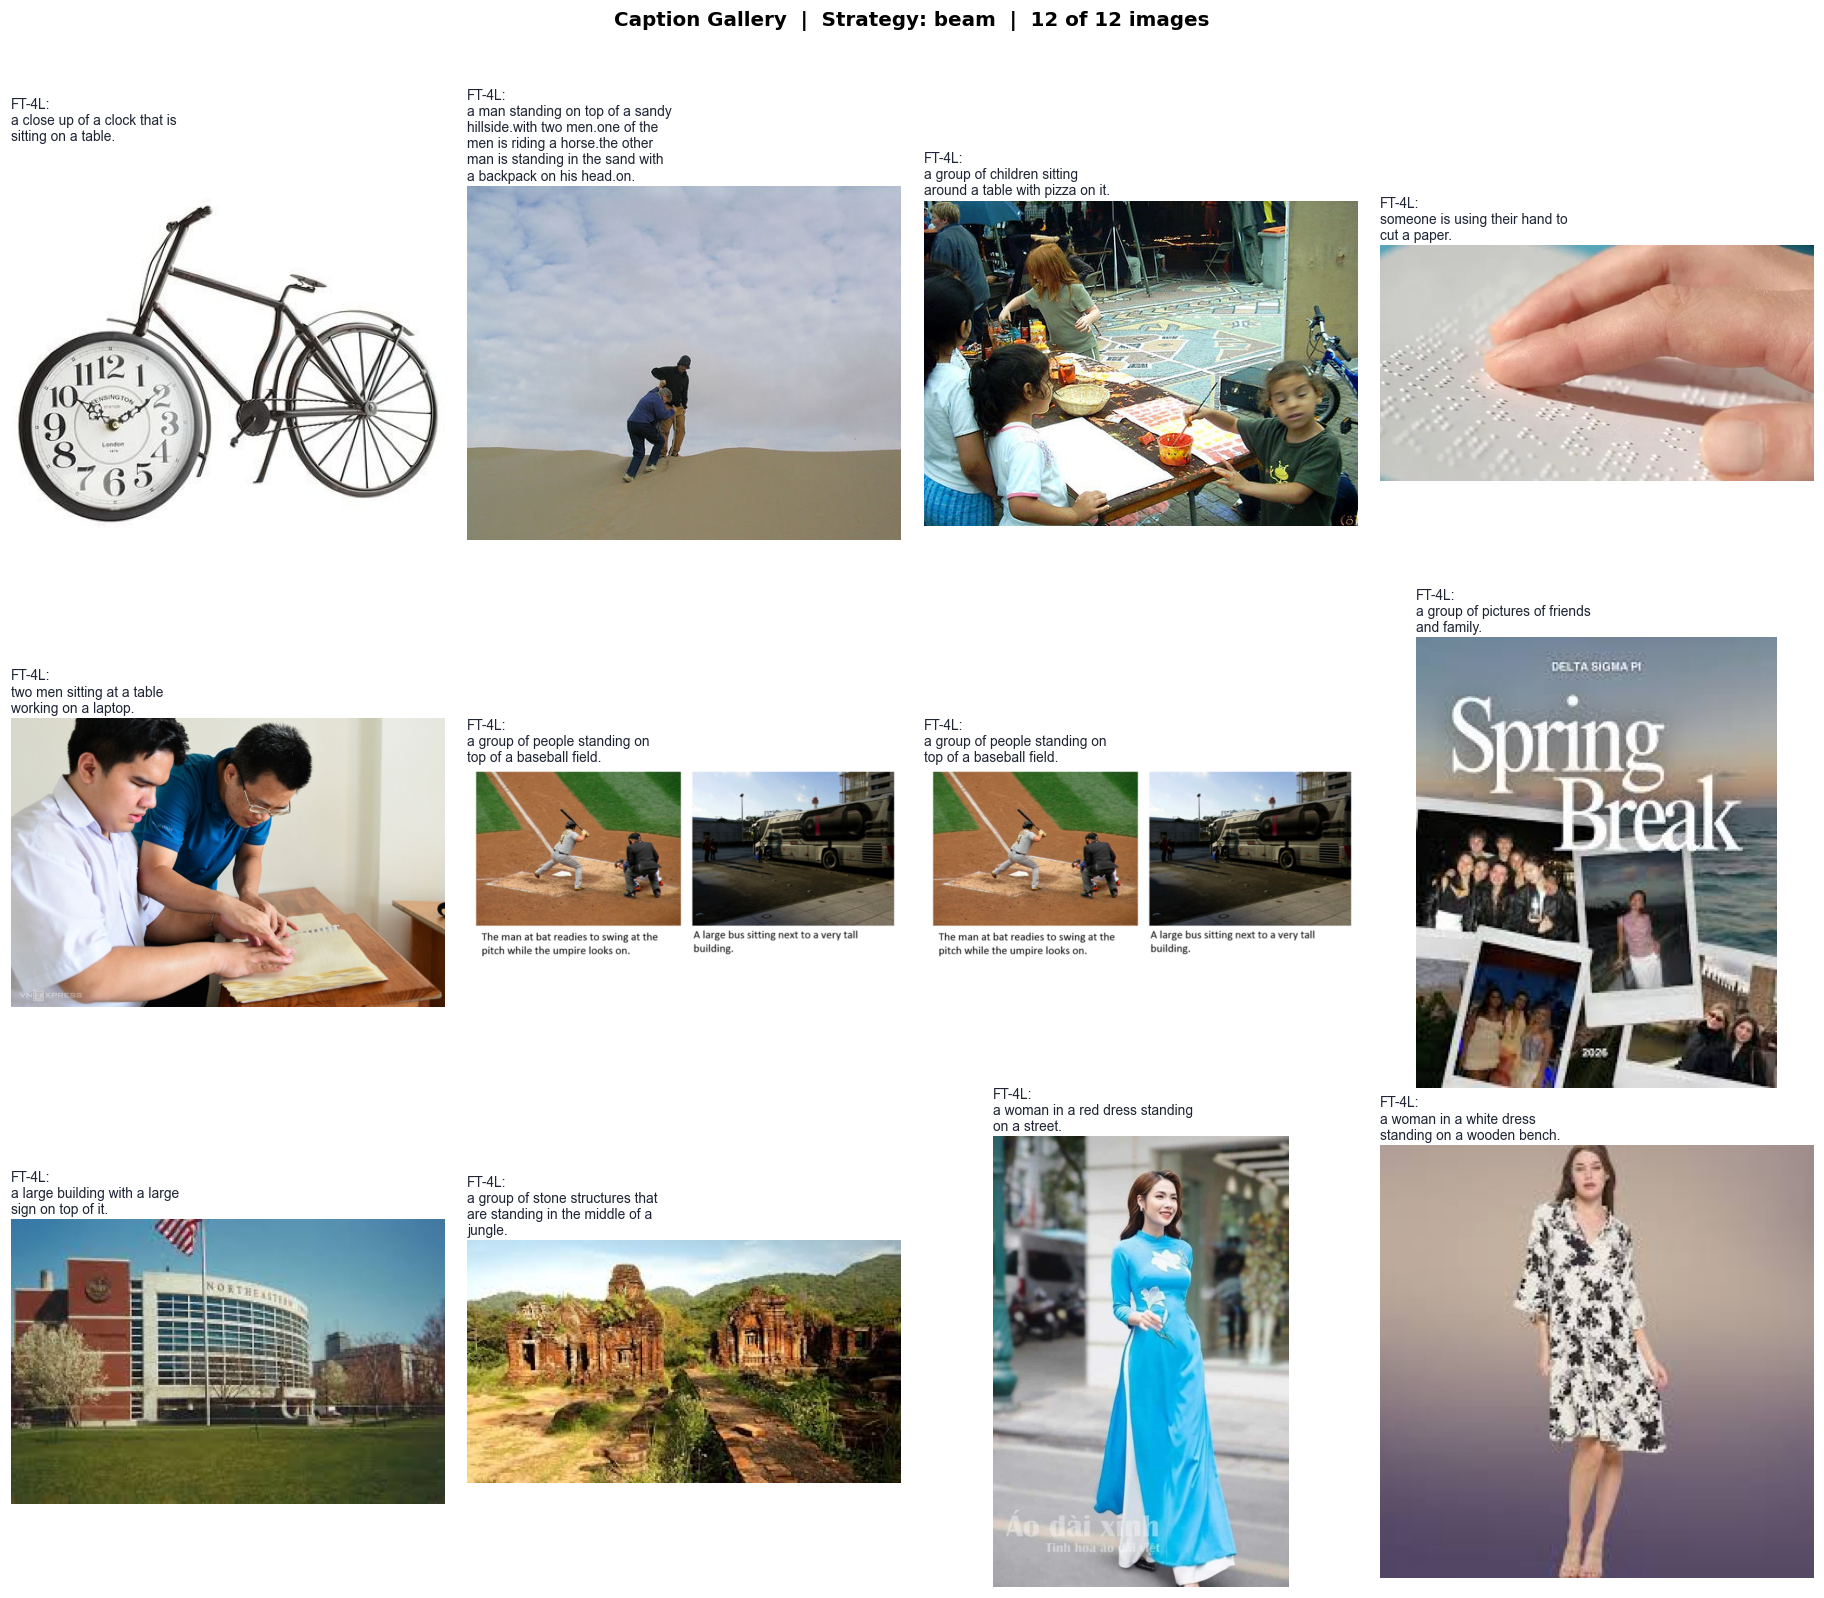

Gallery saved to outputs/figures/caption_gallery.png


In [11]:
GALLERY_COLS = 4
GALLERY_N    = min(12, len(image_paths))

model_names   = list(active_models.keys())
strategy_show = strategies[0]

rows_needed = math.ceil(GALLERY_N / GALLERY_COLS)

fig, axes = plt.subplots(
    rows_needed, GALLERY_COLS,
    figsize=(GALLERY_COLS * 4.2, rows_needed * 4.8)
)
axes = np.array(axes).reshape(-1)

cap_lookup = {
    (r['img_idx'], r['model'], r['strategy']): r['caption']
    for r in results
}
palette = {'Frozen': '#2563eb', 'FT-4L': '#d97706', 'LoRA': '#e86020'}

for i in range(GALLERY_N):
    ax = axes[i]
    img = Image.open(image_paths[i]).convert('RGB')
    ax.imshow(img)
    ax.axis('off')

    # Build caption text per model — no CLIPScore tags
    text_lines = []
    for mn in model_names:
        cap = cap_lookup.get((i, mn, strategy_show), '')
        # Wrap at 32 chars
        words = cap.split()
        wrapped, line_len = '', 0
        for w in words:
            if line_len + len(w) > 32:
                wrapped += '\n'
                line_len = 0
            wrapped += w + ' '
            line_len += len(w) + 1
        text_lines.append(f'{mn}:\n{wrapped.strip()}')

    label = '\n\n'.join(text_lines)
    ax.set_title(
        label,
        fontsize=9,
        loc='left',
        pad=4,
        family='Arial',
        color='#1e2433',
    )

for j in range(GALLERY_N, len(axes)):
    axes[j].set_visible(False)

extra = f'  (+{len(image_paths) - GALLERY_N} more)' if len(image_paths) > GALLERY_N else ''
fig.suptitle(
    f'Caption Gallery  |  Strategy: {strategy_show}  |  '
    f'{GALLERY_N} of {len(image_paths)} images{extra}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(pad=1.5)
plt.savefig(
    PROJECT_ROOT / 'outputs' / 'figures' / 'caption_gallery.png',
    dpi=130, bbox_inches='tight'
)
plt.show()
print('Gallery saved to outputs/figures/caption_gallery.png')


---
## Section 8: Average Metrics Table

Aggregated metrics per model and strategy across all evaluated images.

In [12]:
from collections import defaultdict

groups = defaultdict(lambda: defaultdict(list))
for r in results:
    key = (r['model'], r['strategy'])
    groups[key]['clip_score'].append(r['clip_score'])
    groups[key]['perplexity'].append(r['perplexity'])
    groups[key]['time_s'].append(r['time_s'])

avg_rows = []
for (model, strategy), vals in sorted(groups.items()):
    avg_rows.append({
        'Model':      model,
        'Strategy':   strategy,
        'CLIPScore':  round(np.mean(vals['clip_score']), 2),
        'Perplexity': round(np.mean(vals['perplexity']), 1),
        'Latency(s)': round(np.mean(vals['time_s']), 3),
    })

best_cs  = max(r['CLIPScore']  for r in avg_rows)
best_ppl = min(r['Perplexity'] for r in avg_rows)

header_bg     = '#1e2433'
model_colors  = {'Frozen': '#eff6ff', 'FT-4L': '#fffbeb', 'LoRA': '#fff7ed'}
model_text    = {'Frozen': '#2563eb', 'FT-4L': '#d97706', 'LoRA': '#e86020'}

def td(val, best, lower=False):
    is_best = (val == best)
    color   = '#e86020' if is_best else '#1e2433'
    weight  = 'bold'    if is_best else 'normal'
    return (f"<td style='padding:7px 14px;text-align:right;"
            f"color:{color};font-weight:{weight}'>{val}</td>")

header_cells = ''.join(
    f"<th style='padding:8px 14px;text-align:"
    f"{'left' if c in ('Model','Strategy') else 'right'};"
    f"color:#fff'>{c}</th>"
    for c in ['Model', 'Strategy', 'CLIPScore', 'Perplexity', 'Latency(s)']
)

body = ''
for row in avg_rows:
    bg = model_colors.get(row['Model'], '#fff')
    mc = model_text.get(row['Model'], '#1e2433')
    tds = (
        f"<td style='padding:7px 14px;font-weight:bold;color:{mc}'>{row['Model']}</td>"
        f"<td style='padding:7px 14px;font-family:monospace;color:#4a5368'>{row['Strategy']}</td>"
    )
    tds += td(row['CLIPScore'],  best_cs)
    tds += td(row['Perplexity'], best_ppl, lower=True)
    tds += (f"<td style='padding:7px 14px;text-align:right;color:#4a5368'>"
            f"{row['Latency(s)']}</td>")
    body += (
        f"<tr style='background:{bg};border-bottom:1px solid #dce1eb'>"
        f"{tds}</tr>"
    )

display(HTML(f"""
<div style='font-family:Arial,sans-serif;font-size:13px;margin-top:8px'>
  <div style='font-weight:bold;font-size:15px;margin-bottom:6px;color:#1e2433'>
    Average Metrics  ({len(image_paths)} images)
  </div>
  <div style='font-size:11px;color:#4a5368;margin-bottom:10px'>
    Orange = best value.  Perplexity: lower is better.  CLIPScore range 0-100.
  </div>
  <table style='border-collapse:collapse;width:100%'>
    <thead><tr style='background:{header_bg}'>{header_cells}</tr></thead>
    <tbody>{body}</tbody>
  </table>
</div>
"""))


Model,Strategy,CLIPScore,Perplexity,Latency(s)
FT-4L,beam,26.8,33.0,1.252


---
## Section 9: Performance Charts (Reference + Reference-Free Metrics)

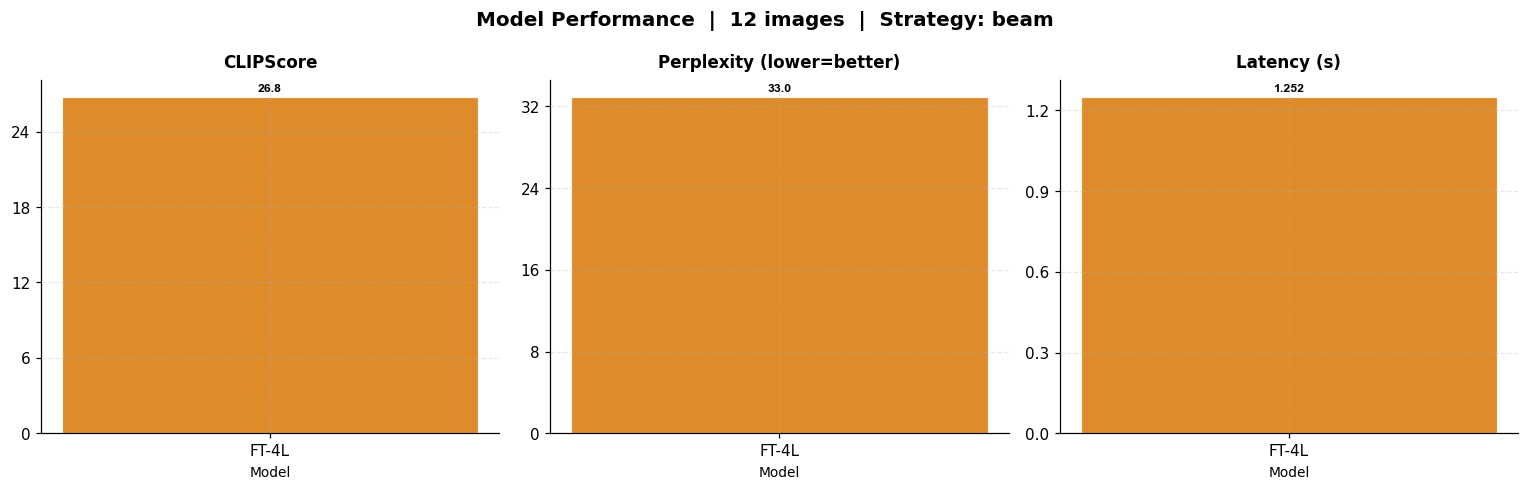

Chart saved to outputs/figures/performance_summary.png


In [13]:
palette = {'Frozen': '#2563eb', 'FT-4L': '#d97706', 'LoRA': '#e86020'}
model_names_avail = list(active_models.keys())
x = np.arange(len(model_names_avail))
bar_w = 0.22

def get_avg(model, strategy, metric):
    vals = [r[metric] for r in results
            if r['model'] == model and r['strategy'] == strategy
            and r.get(metric) is not None]
    return np.mean(vals) if vals else 0.0

metrics_free = [
    ('CLIPScore', 'clip_score'),
    ('Perplexity (lower=better)', 'perplexity'),
    ('Latency (s)', 'time_s'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (metric_label, metric_key) in zip(axes, metrics_free):
    for s_i, strategy in enumerate(strategies):
        vals = [get_avg(mn, strategy, metric_key) for mn in model_names_avail]
        offset = (s_i - len(strategies) / 2 + 0.5) * bar_w
        bars = ax.bar(
            x + offset, vals, width=bar_w,
            label=strategy,
            color=[palette.get(mn, '#888') for mn in model_names_avail],
            alpha=0.85, edgecolor='white', linewidth=0.8
        )
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f'{v:.3f}' if v < 10 else f'{v:.1f}',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold',
                    family='Arial'
                )
    ax.set_title(metric_label, fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_avail, fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_xlabel('Model', fontsize=9)
    if len(strategies) > 1:
        ax.legend(title='Strategy', fontsize=8)

fig.suptitle(
    f'Model Performance  |  {len(image_paths)} images  |  Strategy: {STRATEGY}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'outputs' / 'figures' / 'performance_summary.png',
    dpi=130, bbox_inches='tight'
)
plt.show()
print('Chart saved to outputs/figures/performance_summary.png')


---
## Section 10: Beam Width Sweep

Evaluates how CIDEr-proxy (CLIPScore) and BLEU-4 change as beam width increases, on a subset of images.

Beam width sweep on 10 images using model: FT-4L


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  w= 1  CLIPScore=27.40  Perplexity=47.1
  w= 2  CLIPScore=26.45  Perplexity=34.4
  w= 3  CLIPScore=26.99  Perplexity=32.9
  w= 5  CLIPScore=27.37  Perplexity=34.4
  w= 8  CLIPScore=27.54  Perplexity=24.6
  w=10  CLIPScore=27.76  Perplexity=26.2


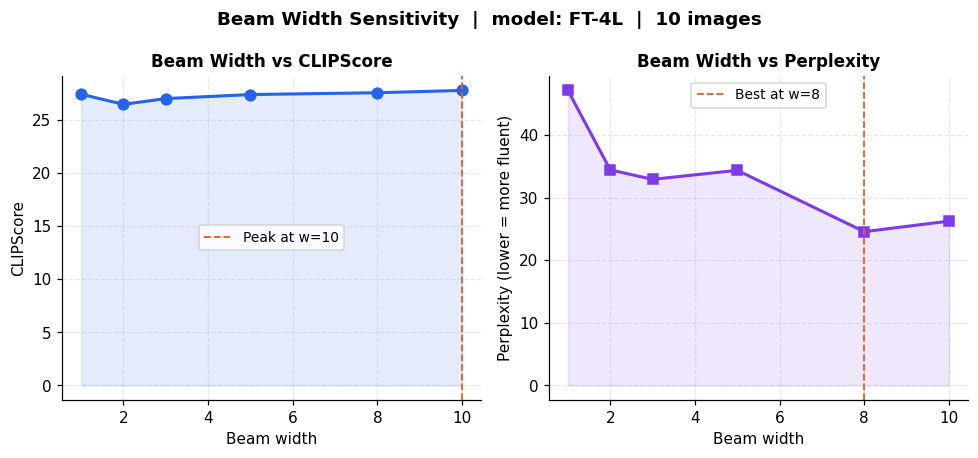

Chart saved to outputs/figures/beam_sweep.png


In [14]:
# Config for sweep
SWEEP_N_IMAGES  = min(10, len(image_paths))    # subset for speed
SWEEP_MODEL     = list(active_models.keys())[0]  # which model to sweep
BEAM_WIDTHS     = [1, 2, 3, 5, 8, 10]
SWEEP_GT        = GROUND_TRUTH[:SWEEP_N_IMAGES] if has_gt else []

sweep_images    = image_paths[:SWEEP_N_IMAGES]
sweep_model_obj = active_models[SWEEP_MODEL]

beam_clip, beam_bleu4, beam_ppl = [], [], []

print(f'Beam width sweep on {SWEEP_N_IMAGES} images using model: {SWEEP_MODEL}')
for bw in BEAM_WIDTHS:
    cs_vals, b4_vals, ppl_vals = [], [], []
    for idx, img_path in enumerate(sweep_images):
        pil_img   = Image.open(img_path).convert('RGB')
        embedding = encode_image(pil_img)
        cap = clean_caption(
            sweep_model_obj.generate(
                embedding, strategy='beam', num_beams=bw,
                max_new_tokens=MAX_NEW_TOKENS, tokenizer=tokenizer
            ),
            max_sentences=MAX_SENTENCES
        )
        cs_vals.append(compute_clip_score(pil_img, cap))
        ppl_vals.append(compute_perplexity(cap))
        if SWEEP_GT:
            b4_vals.append(compute_bleu(cap, SWEEP_GT[idx], n=4))

    beam_clip.append(np.mean(cs_vals))
    beam_ppl.append(np.mean(ppl_vals))
    beam_bleu4.append(np.mean(b4_vals) if b4_vals else None)
    print(f'  w={bw:2d}  CLIPScore={beam_clip[-1]:.2f}  Perplexity={beam_ppl[-1]:.1f}'
          + (f'  BLEU-4={beam_bleu4[-1]:.4f}' if beam_bleu4[-1] is not None else ''))

# ── Plot
n_plots = 3 if SWEEP_GT else 2
fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots, 4.2))

axes[0].plot(BEAM_WIDTHS, beam_clip, marker='o', color='#2563eb', linewidth=2, markersize=7)
axes[0].fill_between(BEAM_WIDTHS, beam_clip, alpha=0.12, color='#2563eb')
axes[0].set_title('Beam Width vs CLIPScore', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Beam width')
axes[0].set_ylabel('CLIPScore')
best_bw_cs = BEAM_WIDTHS[np.argmax(beam_clip)]
axes[0].axvline(best_bw_cs, color='#e86020', linestyle='--', linewidth=1.2,
                label=f'Peak at w={best_bw_cs}')
axes[0].legend(fontsize=9)

axes[1].plot(BEAM_WIDTHS, beam_ppl, marker='s', color='#7c3aed', linewidth=2, markersize=7)
axes[1].fill_between(BEAM_WIDTHS, beam_ppl, alpha=0.12, color='#7c3aed')
axes[1].set_title('Beam Width vs Perplexity', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Beam width')
axes[1].set_ylabel('Perplexity (lower = more fluent)')
best_bw_ppl = BEAM_WIDTHS[np.argmin(beam_ppl)]
axes[1].axvline(best_bw_ppl, color='#e86020', linestyle='--', linewidth=1.2,
                label=f'Best at w={best_bw_ppl}')
axes[1].legend(fontsize=9)

if n_plots == 3 and any(v is not None for v in beam_bleu4):
    clean_bw = [bw for bw, v in zip(BEAM_WIDTHS, beam_bleu4) if v is not None]
    clean_b4 = [v for v in beam_bleu4 if v is not None]
    axes[2].plot(clean_bw, clean_b4, marker='^', color='#16a34a', linewidth=2, markersize=7)
    axes[2].fill_between(clean_bw, clean_b4, alpha=0.12, color='#16a34a')
    axes[2].set_title('Beam Width vs BLEU-4', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Beam width')
    axes[2].set_ylabel('BLEU-4')
    best_bw_b4 = clean_bw[np.argmax(clean_b4)]
    axes[2].axvline(best_bw_b4, color='#e86020', linestyle='--', linewidth=1.2,
                    label=f'Peak at w={best_bw_b4}')
    axes[2].legend(fontsize=9)

fig.suptitle(f'Beam Width Sensitivity  |  model: {SWEEP_MODEL}  |  {SWEEP_N_IMAGES} images',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'beam_sweep.png',
            dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/figures/beam_sweep.png')

---
## Section 11: Temperature Sweep (Nucleus Sampling)

Evaluates accuracy vs diversity trade-off as temperature increases.

Temperature sweep on 10 images using model: FT-4L
  t=0.3  CLIPScore=27.20  Distinct-2=0.821
  t=0.5  CLIPScore=27.38  Distinct-2=0.864
  t=0.7  CLIPScore=27.09  Distinct-2=0.901


2026-04-14 23:24:24.687 Python[29573:984601] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-29573-2026-04-14_23_24_24-507208012‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-04-14 23:24:24.717 Python[29573:984601] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-29573-2026-04-14_23_24_24-408308911‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-04-14 23:24:24.757 Python[29573:984601] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-29573-2026-04-14_23_24_24-1805557185‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-04-14 23:24:24.873 Python[29573:984601] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-29573-2026-04-14_23_24_24-2482869714‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of s

  t=0.8  CLIPScore=26.48  Distinct-2=0.905
  t=1.0  CLIPScore=26.02  Distinct-2=0.942
  t=1.2  CLIPScore=24.05  Distinct-2=0.960


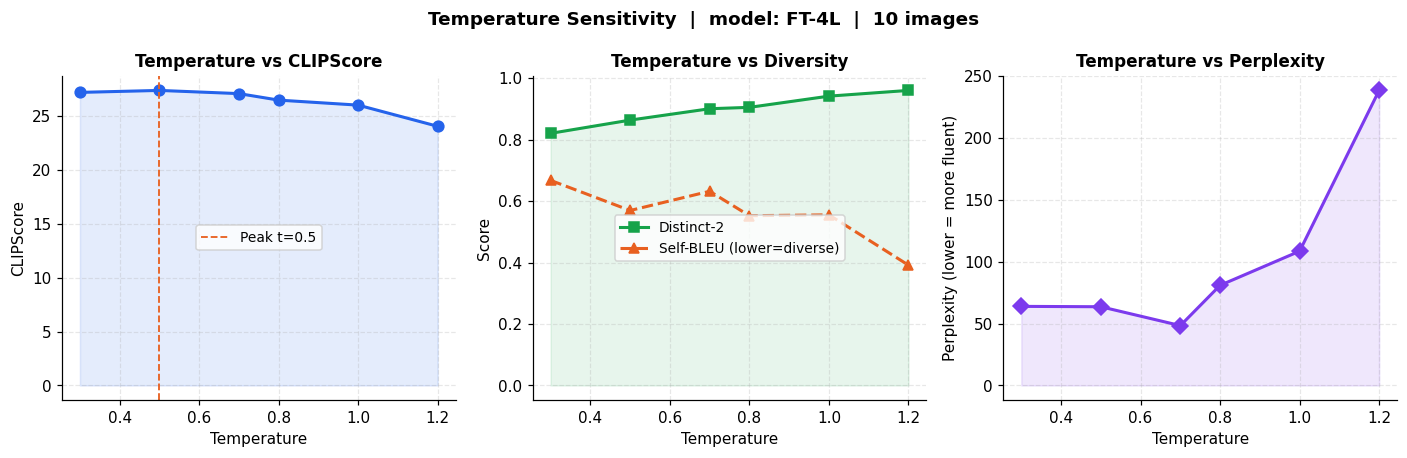

Chart saved to outputs/figures/temperature_sweep.png


In [15]:
TEMPERATURES  = [0.3, 0.5, 0.7, 0.8, 1.0, 1.2]
TEMP_MODEL    = list(active_models.keys())[0]
temp_model_obj = active_models[TEMP_MODEL]

temp_clip, temp_ppl, temp_d2, temp_selfbleu, temp_bleu4 = [], [], [], [], []

print(f'Temperature sweep on {SWEEP_N_IMAGES} images using model: {TEMP_MODEL}')
for t in TEMPERATURES:
    cs_vals, ppl_vals, caps_this_temp, b4_vals = [], [], [], []
    for idx, img_path in enumerate(sweep_images):
        pil_img   = Image.open(img_path).convert('RGB')
        embedding = encode_image(pil_img)
        cap = clean_caption(
            temp_model_obj.generate(
                embedding, strategy='nucleus',
                temperature=t, top_p=TOP_P,
                max_new_tokens=MAX_NEW_TOKENS, tokenizer=tokenizer
            ),
            max_sentences=MAX_SENTENCES
        )
        cs_vals.append(compute_clip_score(pil_img, cap))
        ppl_vals.append(compute_perplexity(cap))
        caps_this_temp.append(cap)
        if SWEEP_GT:
            b4_vals.append(compute_bleu(cap, SWEEP_GT[idx], n=4))

    temp_clip.append(np.mean(cs_vals))
    temp_ppl.append(np.mean(ppl_vals))
    temp_d2.append(compute_distinct2(caps_this_temp))
    temp_selfbleu.append(compute_self_bleu(caps_this_temp))
    temp_bleu4.append(np.mean(b4_vals) if b4_vals else None)
    print(f'  t={t}  CLIPScore={temp_clip[-1]:.2f}  Distinct-2={temp_d2[-1]:.3f}'
          + (f'  BLEU-4={temp_bleu4[-1]:.4f}' if temp_bleu4[-1] is not None else ''))

# ── Plot
n_plots = 4 if SWEEP_GT else 3
fig, axes = plt.subplots(1, n_plots, figsize=(4.3 * n_plots, 4.2))

axes[0].plot(TEMPERATURES, temp_clip, marker='o', color='#2563eb', linewidth=2, markersize=7)
axes[0].fill_between(TEMPERATURES, temp_clip, alpha=0.12, color='#2563eb')
axes[0].set_title('Temperature vs CLIPScore', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('CLIPScore')
axes[0].axvline(TEMPERATURES[np.argmax(temp_clip)], color='#e86020',
                linestyle='--', linewidth=1.2,
                label=f'Peak t={TEMPERATURES[np.argmax(temp_clip)]}')
axes[0].legend(fontsize=9)

axes[1].plot(TEMPERATURES, temp_d2, marker='s', color='#16a34a', linewidth=2, markersize=7,
             label='Distinct-2')
axes[1].plot(TEMPERATURES, temp_selfbleu, marker='^', color='#e86020', linewidth=2,
             linestyle='--', markersize=7, label='Self-BLEU (lower=diverse)')
axes[1].fill_between(TEMPERATURES, temp_d2, alpha=0.1, color='#16a34a')
axes[1].set_title('Temperature vs Diversity', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)

axes[2].plot(TEMPERATURES, temp_ppl, marker='D', color='#7c3aed', linewidth=2, markersize=7)
axes[2].fill_between(TEMPERATURES, temp_ppl, alpha=0.12, color='#7c3aed')
axes[2].set_title('Temperature vs Perplexity', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Perplexity (lower = more fluent)')

if n_plots == 4 and any(v is not None for v in temp_bleu4):
    clean_t  = [t for t, v in zip(TEMPERATURES, temp_bleu4) if v is not None]
    clean_b4 = [v for v in temp_bleu4 if v is not None]
    axes[3].plot(clean_t, clean_b4, marker='o', color='#d97706', linewidth=2, markersize=7)
    axes[3].fill_between(clean_t, clean_b4, alpha=0.12, color='#d97706')
    axes[3].set_title('Temperature vs BLEU-4', fontsize=11, fontweight='bold')
    axes[3].set_xlabel('Temperature')
    axes[3].set_ylabel('BLEU-4')

fig.suptitle(f'Temperature Sensitivity  |  model: {TEMP_MODEL}  |  {SWEEP_N_IMAGES} images',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'temperature_sweep.png',
            dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/figures/temperature_sweep.png')

---
## Section 12: Per-Image Detailed Caption Table

Shows image thumbnail alongside captions from all models, with per-caption metrics.

Image,Model,Strategy,Caption,CLIPScore,Perplexity,Time(s)
,FT-4L,beam,a close up of a clock that is sitting on a table.,23.6,35.1,2.047
,FT-4L,beam,a man standing on top of a sandy hillside.with two men.one of the men is riding a horse.the other man is standing in the sand with a backpack on his head.on.,34.3,20.0,1.172
,FT-4L,beam,a group of children sitting around a table with pizza on it.,36.1,40.5,1.273
,FT-4L,beam,someone is using their hand to cut a paper.,30.6,64.4,1.255
,FT-4L,beam,two men sitting at a table working on a laptop.,27.0,23.4,1.152
,FT-4L,beam,a group of people standing on top of a baseball field.,22.3,25.1,1.153
,FT-4L,beam,a group of people standing on top of a baseball field.,22.3,25.1,1.334
,FT-4L,beam,a group of pictures of friends and family.,25.0,58.3,1.133
,FT-4L,beam,a large building with a large sign on top of it.,26.0,18.5,1.094
,FT-4L,beam,a group of stone structures that are standing in the middle of a jungle.,26.6,33.2,1.077

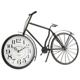
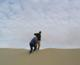
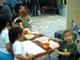
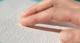
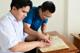
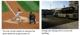
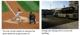
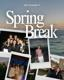
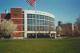
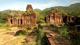

In [16]:
import base64
from io import BytesIO

DETAIL_N = min(10, len(image_paths))

def img_to_b64(path, size=(80, 80)):
    img = Image.open(path).convert('RGB')
    img.thumbnail(size)
    buf = BytesIO()
    img.save(buf, format='JPEG', quality=75)
    return base64.b64encode(buf.getvalue()).decode()

model_colors = {'Frozen': '#2563eb', 'FT-4L': '#d97706', 'LoRA': '#e86020'}
header_bg    = '#1e2433'

header = f"""
<tr style='background:{header_bg};color:#fff'>
  <th style='padding:6px 10px'>Image</th>
  <th style='padding:6px 10px'>Model</th>
  <th style='padding:6px 10px'>Strategy</th>
  <th style='padding:6px 10px;text-align:left'>Caption</th>
  <th style='padding:6px 10px'>CLIPScore</th>
  <th style='padding:6px 10px'>Perplexity</th>
  <th style='padding:6px 10px'>Time(s)</th>
</tr>
"""

rows_html = ''
shown_idx = set()
row_count = 0

for r in results:
    if r['img_idx'] >= DETAIL_N:
        continue
    row_count += 1
    bg = '#f8f9fb' if row_count % 2 == 0 else '#ffffff'
    mc = model_colors.get(r['model'], '#1e2433')

    if r['img_idx'] not in shown_idx:
        shown_idx.add(r['img_idx'])
        b64 = img_to_b64(r['img_path'])
        img_cell = (
            f"<img src='data:image/jpeg;base64,{b64}' "
            f"style='border-radius:4px;display:block'>"
        )
    else:
        img_cell = ''

    rows_html += f"""
<tr style='background:{bg};border-bottom:1px solid #e8ecf2'>
  <td style='padding:6px 10px;text-align:center'>{img_cell}</td>
  <td style='padding:6px 10px;font-weight:bold;color:{mc};font-family:Arial'>{r['model']}</td>
  <td style='padding:6px 10px;font-family:monospace;color:#4a5368'>{r['strategy']}</td>
  <td style='padding:6px 14px;font-size:15px;font-family:Arial;
             color:#1e2433;line-height:1.5'>{r['caption']}</td>
  <td style='padding:6px 10px;text-align:center;font-weight:bold;
             color:#2563eb;font-family:Arial'>{r['clip_score']:.1f}</td>
  <td style='padding:6px 10px;text-align:center;color:#7c3aed;
             font-family:Arial'>{r['perplexity']:.1f}</td>
  <td style='padding:6px 10px;text-align:center;color:#4a5368;
             font-family:Arial'>{r['time_s']:.3f}</td>
</tr>
"""

display(HTML(f"""
<div style='font-family:Arial,sans-serif;font-size:13px'>
  <div style='font-weight:bold;font-size:15px;margin-bottom:8px;color:#1e2433'>
    Per-Image Caption Results  (first {DETAIL_N} images)
  </div>
  <table style='border-collapse:collapse;width:100%'>
    <thead>{header}</thead>
    <tbody>{rows_html}</tbody>
  </table>
</div>
"""))


---
## Section 13: Diversity Analysis (Distinct-2 and Self-BLEU per Model)

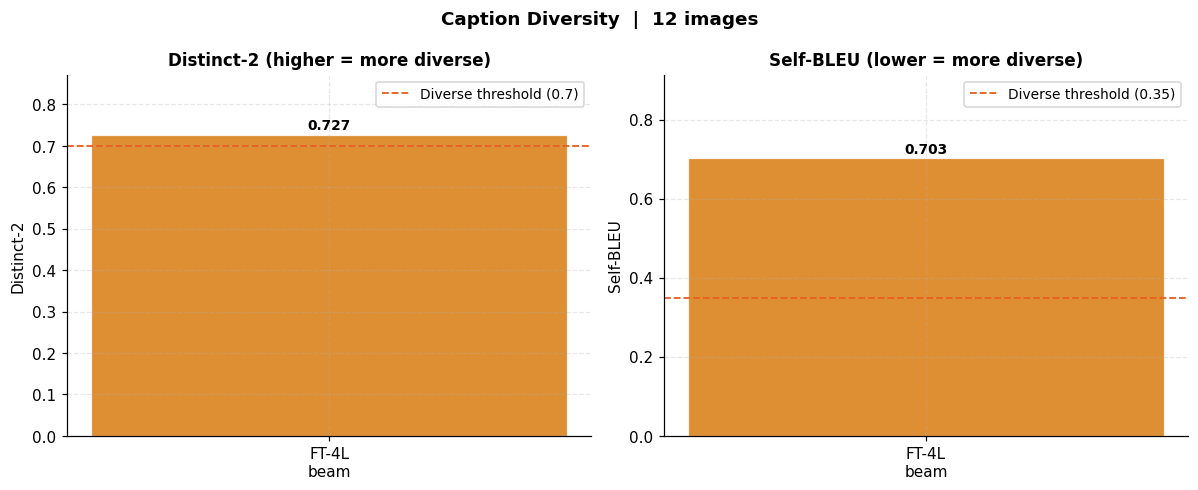

Chart saved to outputs/figures/diversity_analysis.png


In [17]:
# Compute Distinct-2 and Self-BLEU for each (model, strategy) group
div_rows = []
for model_name in model_names_avail:
    for strategy in strategies:
        captions = [
            r['caption'] for r in results
            if r['model'] == model_name and r['strategy'] == strategy
        ]
        if len(captions) < 2:
            continue
        div_rows.append({
            'model':     model_name,
            'strategy':  strategy,
            'distinct2': compute_distinct2(captions),
            'self_bleu': compute_self_bleu(captions),
            'n':         len(captions),
        })

# ── Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

labels = [f"{r['model']}\n{r['strategy']}" for r in div_rows]
d2_vals = [r['distinct2'] for r in div_rows]
sb_vals = [r['self_bleu'] for r in div_rows]
colors  = [palette.get(r['model'], '#888') for r in div_rows]

bars1 = ax1.bar(labels, d2_vals, color=colors, alpha=0.82, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars1, d2_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Distinct-2 (higher = more diverse)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Distinct-2')
ax1.set_ylim(0, min(1.05, max(d2_vals) * 1.2))
ax1.axhline(0.7, color='#e86020', linestyle='--', linewidth=1.2, label='Diverse threshold (0.7)')
ax1.legend(fontsize=9)

bars2 = ax2.bar(labels, sb_vals, color=colors, alpha=0.82, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars2, sb_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Self-BLEU (lower = more diverse)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Self-BLEU')
ax2.set_ylim(0, min(1.05, max(sb_vals) * 1.3))
ax2.axhline(0.35, color='#e86020', linestyle='--', linewidth=1.2, label='Diverse threshold (0.35)')
ax2.legend(fontsize=9)

fig.suptitle(f'Caption Diversity  |  {len(image_paths)} images',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'diversity_analysis.png',
            dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/figures/diversity_analysis.png')

---
## Section 14: Radar Chart: Model Comparison at a Glance

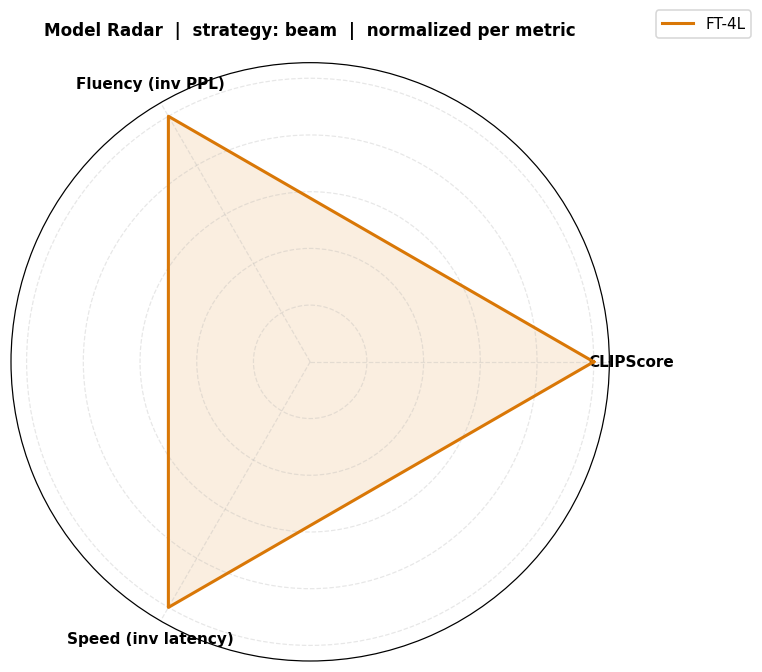

Chart saved to outputs/figures/radar_comparison.png


In [18]:
# Radar chart normalizes each metric to [0, 1] and shows all models together.
# Reference metrics are included only if ground truth is available.

radar_metrics = []
radar_labels  = []

if has_gt:
    radar_metrics += [('bleu4', False), ('meteor', False), ('rouge_l', False)]
    radar_labels  += ['BLEU-4', 'METEOR', 'ROUGE-L']

radar_metrics += [('clip_score', False), ('perplexity', True), ('time_s', True)]
radar_labels  += ['CLIPScore', 'Fluency (inv PPL)', 'Speed (inv latency)']

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

strategy_radar = strategies[0]

# Gather raw values for normalization
raw_vals = {}
for mn in model_names_avail:
    vals = [get_avg(mn, strategy_radar, mk) for mk, _ in radar_metrics]
    raw_vals[mn] = vals

# Normalize per metric
col_mins = [min(raw_vals[mn][i] for mn in model_names_avail) for i in range(N)]
col_maxs = [max(raw_vals[mn][i] for mn in model_names_avail) for i in range(N)]

def normalize(val, lo, hi, invert=False):
    if hi == lo:
        return 0.5
    n = (val - lo) / (hi - lo)
    return 1.0 - n if invert else n

for mn in model_names_avail:
    normed = [
        normalize(raw_vals[mn][i], col_mins[i], col_maxs[i], invert=radar_metrics[i][1])
        for i in range(N)
    ]
    normed += normed[:1]
    ax.plot(angles, normed, linewidth=2, linestyle='solid',
            color=palette.get(mn, '#888'), label=mn)
    ax.fill(angles, normed, alpha=0.12, color=palette.get(mn, '#888'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight='bold')
ax.set_yticklabels([])
ax.set_title(f'Model Radar  |  strategy: {strategy_radar}  |  normalized per metric',
             fontsize=11, fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'radar_comparison.png',
            dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/figures/radar_comparison.png')

---
## Section 15: Summary Report

Prints a clean summary of findings to console.

In [19]:
print('=' * 60)
print('  EVALUATION SUMMARY')
print('=' * 60)
print(f'  Images evaluated : {len(image_paths)}')
print(f'  Models           : {list(active_models.keys())}')
print(f'  Strategies       : {strategies}')
print(f'  Beam width       : {BEAM_WIDTH}')
print(f'  Temperature      : {TEMPERATURE}')
print()

print(f'{"Config":<22}  {"CLIPScore":>10}  {"Perplexity":>11}  {"Latency(s)":>11}')
print('-' * 58)

best_cs_val  = max(r['CLIPScore']  for r in avg_rows)
best_ppl_val = min(r['Perplexity'] for r in avg_rows)

for row in avg_rows:
    config   = f"{row['Model']}/{row['Strategy']}"
    cs_mark  = ' *' if row['CLIPScore']  == best_cs_val  else '  '
    ppl_mark = ' *' if row['Perplexity'] == best_ppl_val else '  '
    print(
        f'{config:<22}{cs_mark}{row["CLIPScore"]:>8.2f}'
        f'{ppl_mark}{row["Perplexity"]:>10.1f}'
        f'  {row["Latency(s)"]:>10.3f}'
    )

print()
print('  * = best value in column')
print()

best_row = max(avg_rows, key=lambda r: r['CLIPScore'])
print(f'  Best CLIPScore : {best_row["Model"]} / {best_row["Strategy"]}'
      f'  ({best_row["CLIPScore"]:.2f})')

if 'beam_clip' in dir() and beam_clip:
    best_bw_idx = np.argmax(beam_clip)
    print(f'  Best beam width : w={BEAM_WIDTHS[best_bw_idx]}'
          f'  (CLIPScore {beam_clip[best_bw_idx]:.2f})')

if 'temp_clip' in dir() and temp_clip:
    best_t_idx = np.argmax(temp_clip)
    print(f'  Best temperature: t={TEMPERATURES[best_t_idx]}'
          f'  (CLIPScore {temp_clip[best_t_idx]:.2f})')

print('=' * 60)


  EVALUATION SUMMARY
  Images evaluated : 12
  Models           : ['FT-4L']
  Strategies       : ['beam']
  Beam width       : 5
  Temperature      : 0.5

Config                   CLIPScore   Perplexity   Latency(s)
----------------------------------------------------------
FT-4L/beam             *   26.80 *      33.0       1.252

  * = best value in column

  Best CLIPScore : FT-4L / beam  (26.80)
  Best beam width : w=10  (CLIPScore 27.76)
  Best temperature: t=0.5  (CLIPScore 27.38)
